# Pipeline Drift Debug — Stationary GPS Analysis

Goal: find which node in the GPS fusion pipeline injects motion when robot is stationary.

Pipeline stages traced:
1. `/gps/fix`                  — raw Gazebo NavSat (UNKNOWN covariance, position scatter)
2. `/gps/fix/covariance_fixed` — `gps_covariance_relay.py` output (covariance injected)
3. `/odometry/gps`             — `navsat_transform_node` output (lat/lon → XY in map frame)
4. `/odometry/local`           — EKF#1 (no GPS)
5. `/odometry/global`          — EKF#2 (with GPS)
6. `/ground_truth/odom`        — true Gazebo pose (zero noise reference)

**Record with:**
```bash
bash /home/anish/Multi-sensor-fusion/record_stationary_pipeline.sh
```
Let robot sit for 60-120s. Do NOT touch teleop.

In [103]:
# ── SET BAG PATH ──────────────────────────────────────────────────────────────
BAG_PATH = '/home/rosdata/rosbags/stationary_pipeline_20260509_013439'  # update after recording
PLOT_DIR = '/home/anish/Multi-sensor-fusion/plots/pipeline_debug'
# ─────────────────────────────────────────────────────────────────────────────

import os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import welch
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

# Auto-find latest bag if path uses _LATEST suffix
if BAG_PATH.endswith('_LATEST'):
    candidates = sorted(glob.glob('/home/rosdata/rosbags/stationary_pipeline_*'))
    if candidates:
        BAG_PATH = candidates[-1]
        print(f'Auto-resolved BAG_PATH → {BAG_PATH}')

os.makedirs(PLOT_DIR, exist_ok=True)
typestore = get_typestore(Stores.ROS2_HUMBLE)

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0', 'xtick.color': '#aaaaaa', 'ytick.color': '#aaaaaa',
    'grid.color': '#2a2a4a', 'grid.alpha': 0.5,
    'legend.facecolor': '#16213e', 'legend.edgecolor': '#444444',
    'font.size': 10, 'figure.dpi': 100,
})

C = {
    'gps_raw':       '#ffd43b',
    'gps_relay':     '#ff922b',
    'odom_gps':      '#fa5252',
    'ekf_local':     '#51cf66',
    'ekf_global':    '#339af0',
    'ground_truth':  '#ffffff',
    'imu':           '#20c997',
    'wheel':         '#ff6b6b',
    'visual':        '#a29bfe',
    'lidar':         '#74b9ff',
}

def quat_to_yaw(q):
    siny_cosp = 2.0 * (q.w * q.z + q.x * q.y)
    cosy_cosp = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return np.arctan2(siny_cosp, cosy_cosp)

def npc(df, col):
    return pd.to_numeric(df[col], errors='coerce').to_numpy()

def mfin(*arrs):
    m = np.ones(len(arrs[0]), dtype=bool)
    for a in arrs: m &= np.isfinite(a)
    return m

print(f'Bag: {BAG_PATH}')
print(f'Exists: {Path(BAG_PATH).exists()}')

Bag: /home/rosdata/rosbags/stationary_pipeline_20260509_013439
Exists: True


## 1. Extract All Pipeline Topics

In [104]:
raw = {
    'gps_raw': [], 'gps_relay': [], 'odom_gps': [],
    'ekf_local': [], 'ekf_global': [], 'ground_truth': [],
    'imu': [], 'imu_relay': [], 'wheel': [],
    'visual': [], 'lidar': [],
}

TOPIC_MAP = {
    '/gps/fix':                       'gps_raw',
    '/gps/fix/covariance_fixed':      'gps_relay',
    '/odometry/gps':                  'odom_gps',
    '/odometry/local':                'ekf_local',
    '/odometry/global':               'ekf_global',
    '/ground_truth/odom':             'ground_truth',
    '/imu/data':                      'imu',
    '/imu/data/covariance_fixed':     'imu_relay',
    '/diff_drive_controller/odom':    'wheel',
    '/odometry/visual':               'visual',
    '/odometry/lidar':                'lidar',
}

with AnyReader([Path(BAG_PATH)], default_typestore=typestore) as reader:
    available = list(reader.topics.keys())
    print('Topics in bag:')
    for t in sorted(available): print(f'  {t}')
    print()
    for connection, timestamp, rawdata in reader.messages():
        key = TOPIC_MAP.get(connection.topic)
        if key is None: continue
        msg = reader.deserialize(rawdata, connection.msgtype)
        t = timestamp * 1e-9
        if key in ('gps_raw', 'gps_relay'):
            raw[key].append({
                't': t,
                'lat': msg.latitude, 'lon': msg.longitude, 'alt': msg.altitude,
                'cov_xx': msg.position_covariance[0],
                'cov_yy': msg.position_covariance[4],
                'cov_type': int(msg.position_covariance_type),
            })
        elif key in ('odom_gps', 'ekf_local', 'ekf_global', 'ground_truth', 'wheel', 'visual', 'lidar'):
            raw[key].append({
                't': t,
                'x': msg.pose.pose.position.x, 'y': msg.pose.pose.position.y,
                'yaw': quat_to_yaw(msg.pose.pose.orientation),
                'vx': msg.twist.twist.linear.x, 'vy': msg.twist.twist.linear.y,
                'wz': msg.twist.twist.angular.z,
                'cov_xx':  msg.pose.covariance[0],
                'cov_yy':  msg.pose.covariance[7],
                'cov_yaw': msg.pose.covariance[35],
            })
        elif key in ('imu', 'imu_relay'):
            raw[key].append({
                't': t,
                'gx': msg.angular_velocity.x, 'gy': msg.angular_velocity.y, 'gz': msg.angular_velocity.z,
                'ax': msg.linear_acceleration.x, 'ay': msg.linear_acceleration.y, 'az': msg.linear_acceleration.z,
                'yaw': quat_to_yaw(msg.orientation),
            })

dfs = {}
if not any(raw[k] for k in raw):
    raise RuntimeError('Bag empty or no matching topics')
t0 = min(raw[k][0]['t'] for k in raw if raw[k])
for k, rows in raw.items():
    if rows:
        df = pd.DataFrame(rows)
        df['t'] -= t0
        dfs[k] = df

print(f'\n{"Stage":>14}  {"Msgs":>6}  {"Duration":>9}  {"Rate":>8}')
print('─' * 48)
for k, df in dfs.items():
    dur = df['t'].iloc[-1] - df['t'].iloc[0] if len(df) > 1 else 0
    hz = len(df) / dur if dur > 0 else 0
    print(f'{k:>14}  {len(df):6d}  {dur:8.1f}s  {hz:7.1f} Hz')

Topics in bag:
  /clock
  /diff_drive_controller/odom
  /gps/fix
  /gps/fix/covariance_fixed
  /ground_truth/odom
  /imu/data
  /imu/data/covariance_fixed
  /joint_states
  /odometry/global
  /odometry/gps
  /odometry/lidar
  /odometry/local
  /odometry/visual
  /tf
  /tf_static


         Stage    Msgs   Duration      Rate
────────────────────────────────────────────────
       gps_raw     921     136.2s      6.8 Hz
     gps_relay     921     136.2s      6.8 Hz
      odom_gps     922     136.2s      6.8 Hz
     ekf_local    4605     136.3s     33.8 Hz
    ekf_global    4605     136.3s     33.8 Hz
  ground_truth    4605     136.3s     33.8 Hz
           imu   18421     136.3s    135.2 Hz
     imu_relay   18422     136.3s    135.2 Hz
         wheel    4605     136.3s     33.8 Hz
        visual    1045     136.2s      7.7 Hz
         lidar     460     135.9s      3.4 Hz


## 2. Stage 1 — Raw `/gps/fix` Scatter (Gazebo NavSat plugin output)

Pure sensor noise. No filtering. Convert lat/lon → meters via flat-earth.
If scatter σ ≠ URDF stddev (4.5e-6 deg ≈ 0.5m) → Gazebo plugin bug or wrong noise model.

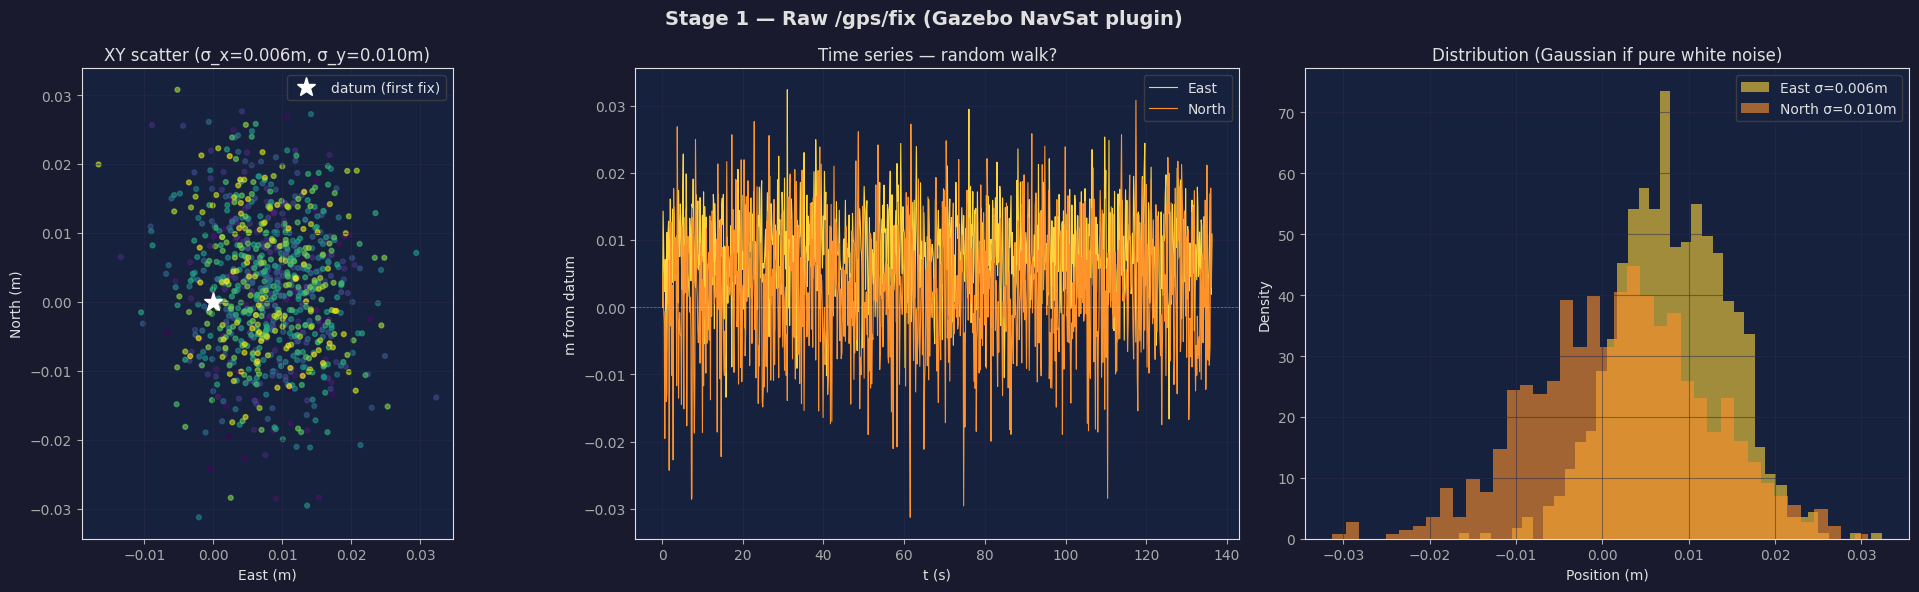


Raw GPS covariance from Gazebo bridge:
  cov_xx values: min=0  max=0  mean=0
  cov_type: {0} (0=UNKNOWN, 1=APPROX, 2=DIAG_KNOWN, 3=KNOWN)

Measured scatter:
  σ_East  = 0.0065 m  → var = 0.0000 m²
  σ_North = 0.0100 m  → var = 0.0001 m²
  URDF expected σ ≈ 0.5 m (stddev=4.5e-6 deg)


In [105]:
if 'gps_raw' not in dfs:
    print('No /gps/fix in bag')
else:
    g = dfs['gps_raw']
    lat = npc(g, 'lat'); lon = npc(g, 'lon'); t = npc(g, 't')
    lat0 = lat[0]
    x_m = (lon - lon[0]) * 111320 * np.cos(np.radians(lat0))
    y_m = (lat - lat0) * 111320

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Stage 1 — Raw /gps/fix (Gazebo NavSat plugin)', fontsize=14, fontweight='bold')

    axes[0].scatter(x_m, y_m, c=t, cmap='viridis', s=12, alpha=0.6)
    axes[0].plot(0, 0, 'w*', ms=14, label='datum (first fix)')
    axes[0].set_xlabel('East (m)'); axes[0].set_ylabel('North (m)')
    axes[0].set_title(f'XY scatter (σ_x={x_m.std():.3f}m, σ_y={y_m.std():.3f}m)')
    axes[0].set_aspect('equal'); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(t, x_m, color=C['gps_raw'], label='East', lw=0.8)
    axes[1].plot(t, y_m, color=C['gps_relay'], label='North', lw=0.8)
    axes[1].axhline(0, color='white', ls='--', lw=0.5, alpha=0.4)
    axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('m from datum')
    axes[1].set_title('Time series — random walk?')
    axes[1].legend(); axes[1].grid(True)

    axes[2].hist(x_m, bins=40, alpha=0.6, color=C['gps_raw'], label=f'East σ={x_m.std():.3f}m', density=True)
    axes[2].hist(y_m, bins=40, alpha=0.6, color=C['gps_relay'], label=f'North σ={y_m.std():.3f}m', density=True)
    axes[2].set_xlabel('Position (m)'); axes[2].set_ylabel('Density')
    axes[2].set_title('Distribution (Gaussian if pure white noise)')
    axes[2].legend(); axes[2].grid(True)

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/01_raw_gps_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

    cov_xx = npc(g, 'cov_xx'); cov_type = npc(g, 'cov_type')
    print(f'\nRaw GPS covariance from Gazebo bridge:')
    print(f'  cov_xx values: min={cov_xx.min():.4g}  max={cov_xx.max():.4g}  mean={cov_xx.mean():.4g}')
    print(f'  cov_type: {set(cov_type.astype(int).tolist())} (0=UNKNOWN, 1=APPROX, 2=DIAG_KNOWN, 3=KNOWN)')
    print(f'\nMeasured scatter:')
    print(f'  σ_East  = {x_m.std():.4f} m  → var = {x_m.std()**2:.4f} m²')
    print(f'  σ_North = {y_m.std():.4f} m  → var = {y_m.std()**2:.4f} m²')
    print(f'  URDF expected σ ≈ 0.5 m (stddev=4.5e-6 deg)')
    if x_m.std() > 1.5:
        print('  ⚠ Real scatter >> URDF stddev → Gazebo NavSat plugin adds extra walk/bias')

## 3. Stage 2 — `/gps/fix/covariance_fixed` Relay Output

Confirm relay only injects covariance, doesn't touch lat/lon. If positions differ → relay bug.

In [106]:
if 'gps_raw' in dfs and 'gps_relay' in dfs:
    gr = dfs['gps_raw']; gf = dfs['gps_relay']
    n = min(len(gr), len(gf))
    dlat = npc(gr, 'lat')[:n] - npc(gf, 'lat')[:n]
    dlon = npc(gr, 'lon')[:n] - npc(gf, 'lon')[:n]
    cov_in  = npc(gr, 'cov_xx')
    cov_out = npc(gf, 'cov_xx')
    print(f'Relay position pass-through check (first {n} aligned msgs):')
    print(f'  max |Δlat| = {np.abs(dlat).max():.4g} deg')
    print(f'  max |Δlon| = {np.abs(dlon).max():.4g} deg')
    print(f'\nCovariance:')
    print(f'  raw   cov_xx: {cov_in.min():.4g} .. {cov_in.max():.4g}')
    print(f'  relay cov_xx: {cov_out.min():.4g} .. {cov_out.max():.4g}')
    if np.abs(dlat).max() > 1e-9:
        print('  ⚠ Relay altering lat/lon — check gps_covariance_relay.py')
    else:
        print('  ✓ Relay is pure pass-through on position')
else:
    print('Need both /gps/fix and /gps/fix/covariance_fixed in bag')

Relay position pass-through check (first 921 aligned msgs):
  max |Δlat| = 0 deg
  max |Δlon| = 0 deg

Covariance:
  raw   cov_xx: 0 .. 0
  relay cov_xx: 0.0001 .. 0.0001
  ✓ Relay is pure pass-through on position


## 4. Stage 3 — `/odometry/gps` (navsat_transform output)

navsat_transform converts lat/lon → XY in `map` frame. If XY scatter > raw GPS scatter → navsat_transform projection or yaw alignment problem.

Compares directly with raw GPS scatter (after meter conversion). They should match within rounding.

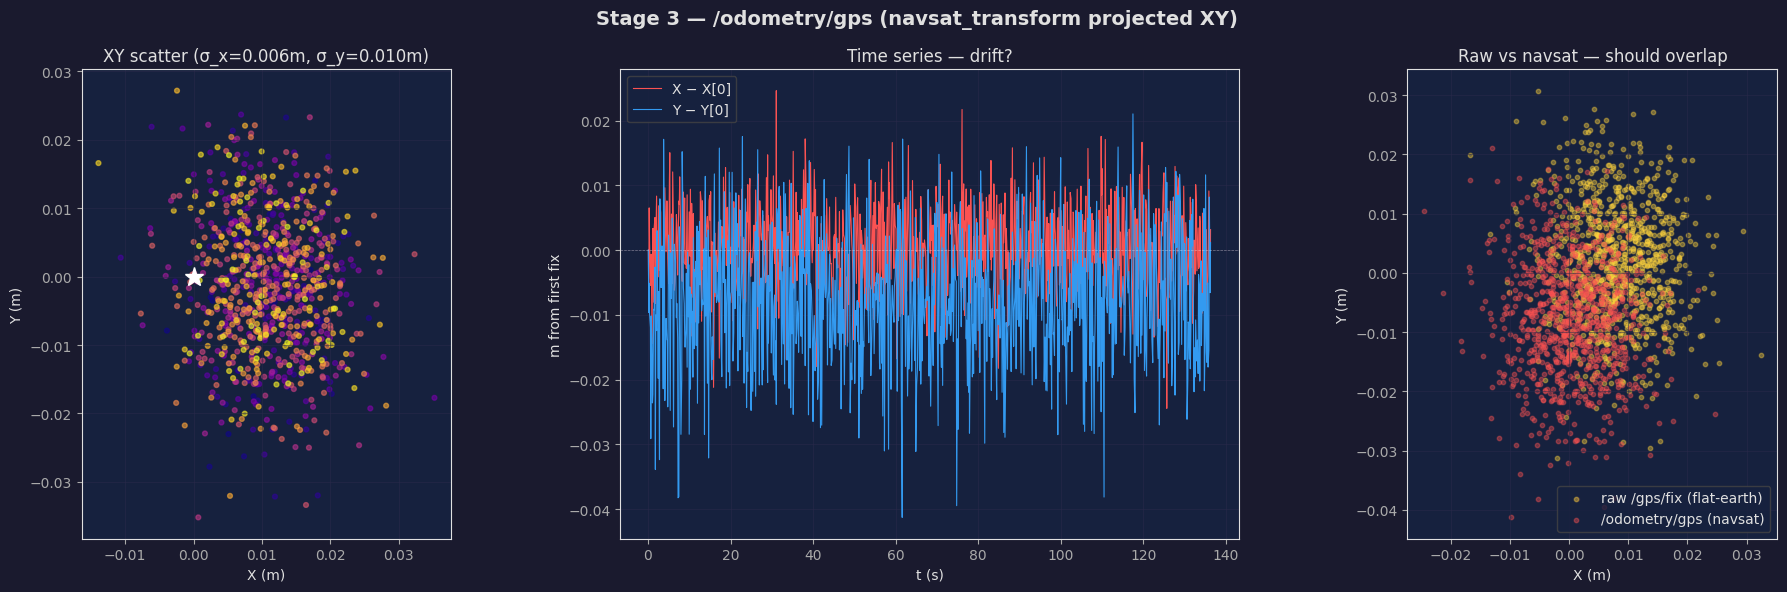


/odometry/gps scatter:
  σ_x = 0.0065 m  σ_y = 0.0100 m
  range x: 0.049 m   range y: 0.062 m
  drift end−start: (+0.0032, +0.0011) m


In [107]:
if 'odom_gps' in dfs:
    og = dfs['odom_gps']
    t = npc(og, 't'); x = npc(og, 'x'); y = npc(og, 'y')

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Stage 3 — /odometry/gps (navsat_transform projected XY)', fontsize=14, fontweight='bold')

    axes[0].scatter(x, y, c=t, cmap='plasma', s=12, alpha=0.6)
    axes[0].plot(0, 0, 'w*', ms=14)
    axes[0].set_xlabel('X (m)'); axes[0].set_ylabel('Y (m)')
    axes[0].set_title(f'XY scatter (σ_x={x.std():.3f}m, σ_y={y.std():.3f}m)')
    axes[0].set_aspect('equal'); axes[0].grid(True)

    axes[1].plot(t, x - x[0], color=C['odom_gps'], label='X − X[0]', lw=0.8)
    axes[1].plot(t, y - y[0], color=C['ekf_global'], label='Y − Y[0]', lw=0.8)
    axes[1].axhline(0, color='white', ls='--', lw=0.5, alpha=0.4)
    axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('m from first fix')
    axes[1].set_title('Time series — drift?')
    axes[1].legend(); axes[1].grid(True)

    if 'gps_raw' in dfs:
        g = dfs['gps_raw']
        lat = npc(g, 'lat'); lon = npc(g, 'lon')
        x_proj = (lon - lon[0]) * 111320 * np.cos(np.radians(lat[0]))
        y_proj = (lat - lat[0]) * 111320
        axes[2].scatter(x_proj, y_proj, c=C['gps_raw'], s=10, alpha=0.4, label='raw /gps/fix (flat-earth)')
        axes[2].scatter(x - x[0], y - y[0], c=C['odom_gps'], s=10, alpha=0.4, label='/odometry/gps (navsat)')
        axes[2].set_xlabel('X (m)'); axes[2].set_ylabel('Y (m)')
        axes[2].set_title('Raw vs navsat — should overlap')
        axes[2].set_aspect('equal'); axes[2].legend(); axes[2].grid(True)

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/02_navsat_output.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n/odometry/gps scatter:')
    print(f'  σ_x = {x.std():.4f} m  σ_y = {y.std():.4f} m')
    print(f'  range x: {(x.max()-x.min()):.3f} m   range y: {(y.max()-y.min()):.3f} m')
    print(f'  drift end−start: ({x[-1]-x[0]:+.4f}, {y[-1]-y[0]:+.4f}) m')
else:
    print('No /odometry/gps in bag')

## 5. Stage 4 — `/odometry/local` (EKF#1, no GPS)

Stationary robot → wheel odom 0, IMU near-zero. EKF#1 should hold ≈origin.
If drifts → IMU bias or wheel slip leaking through (check IMU stationary noise below).

## 4b. Visual + LiDAR Odometry — Stationary Noise Analysis

These feed EKF#2 in differential mode. Stationary, both should report **zero motion**.
Any non-zero scatter = position deltas EKF#2 will integrate as motion.

If σ_x or σ_y > 1mm per frame → differential mode injects fake motion proportional to update rate.

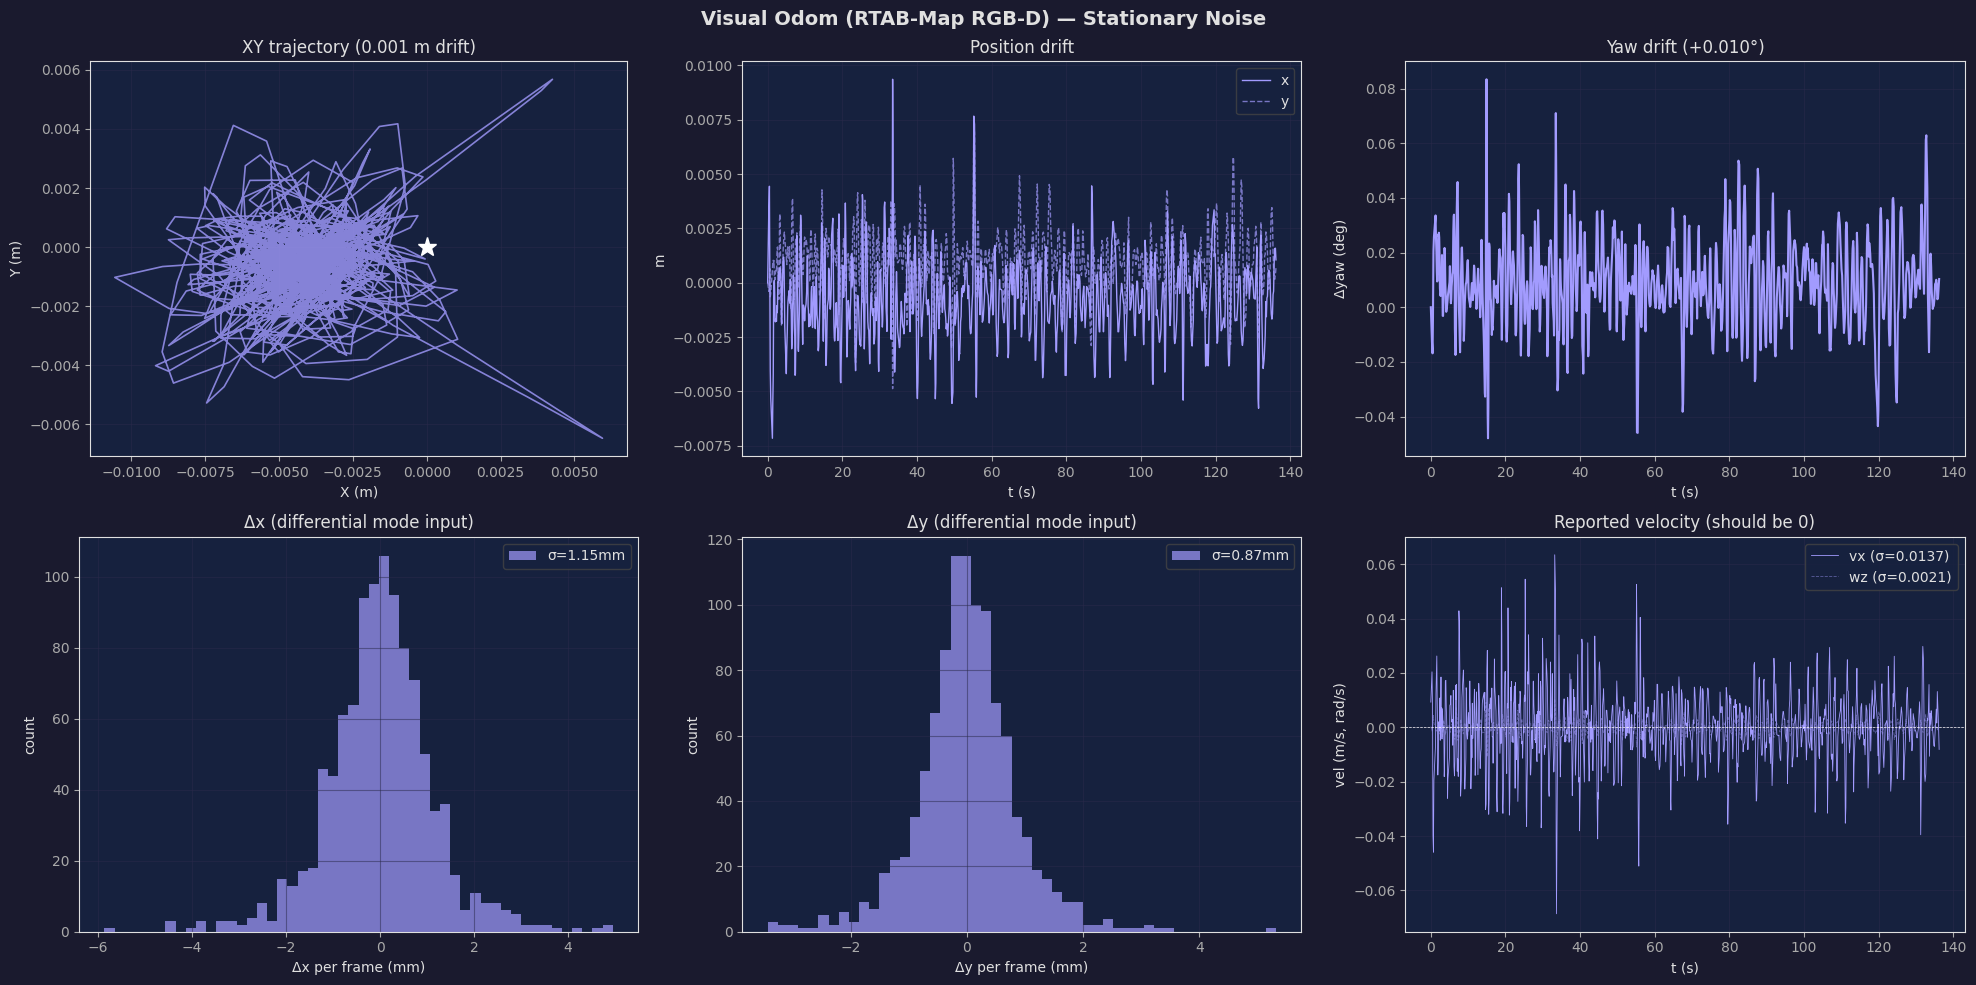

Visual Odom (RTAB-Map RGB-D):
  total drift   : Δx=+0.0011m  Δy=+0.0007m  |Δr|=0.0013m
  yaw drift     : +0.010°
  per-frame Δ σ : x=1.149mm  y=0.871mm  yaw=0.0101°
  velocity σ    : vx=0.01372 m/s  wz=0.00207 rad/s



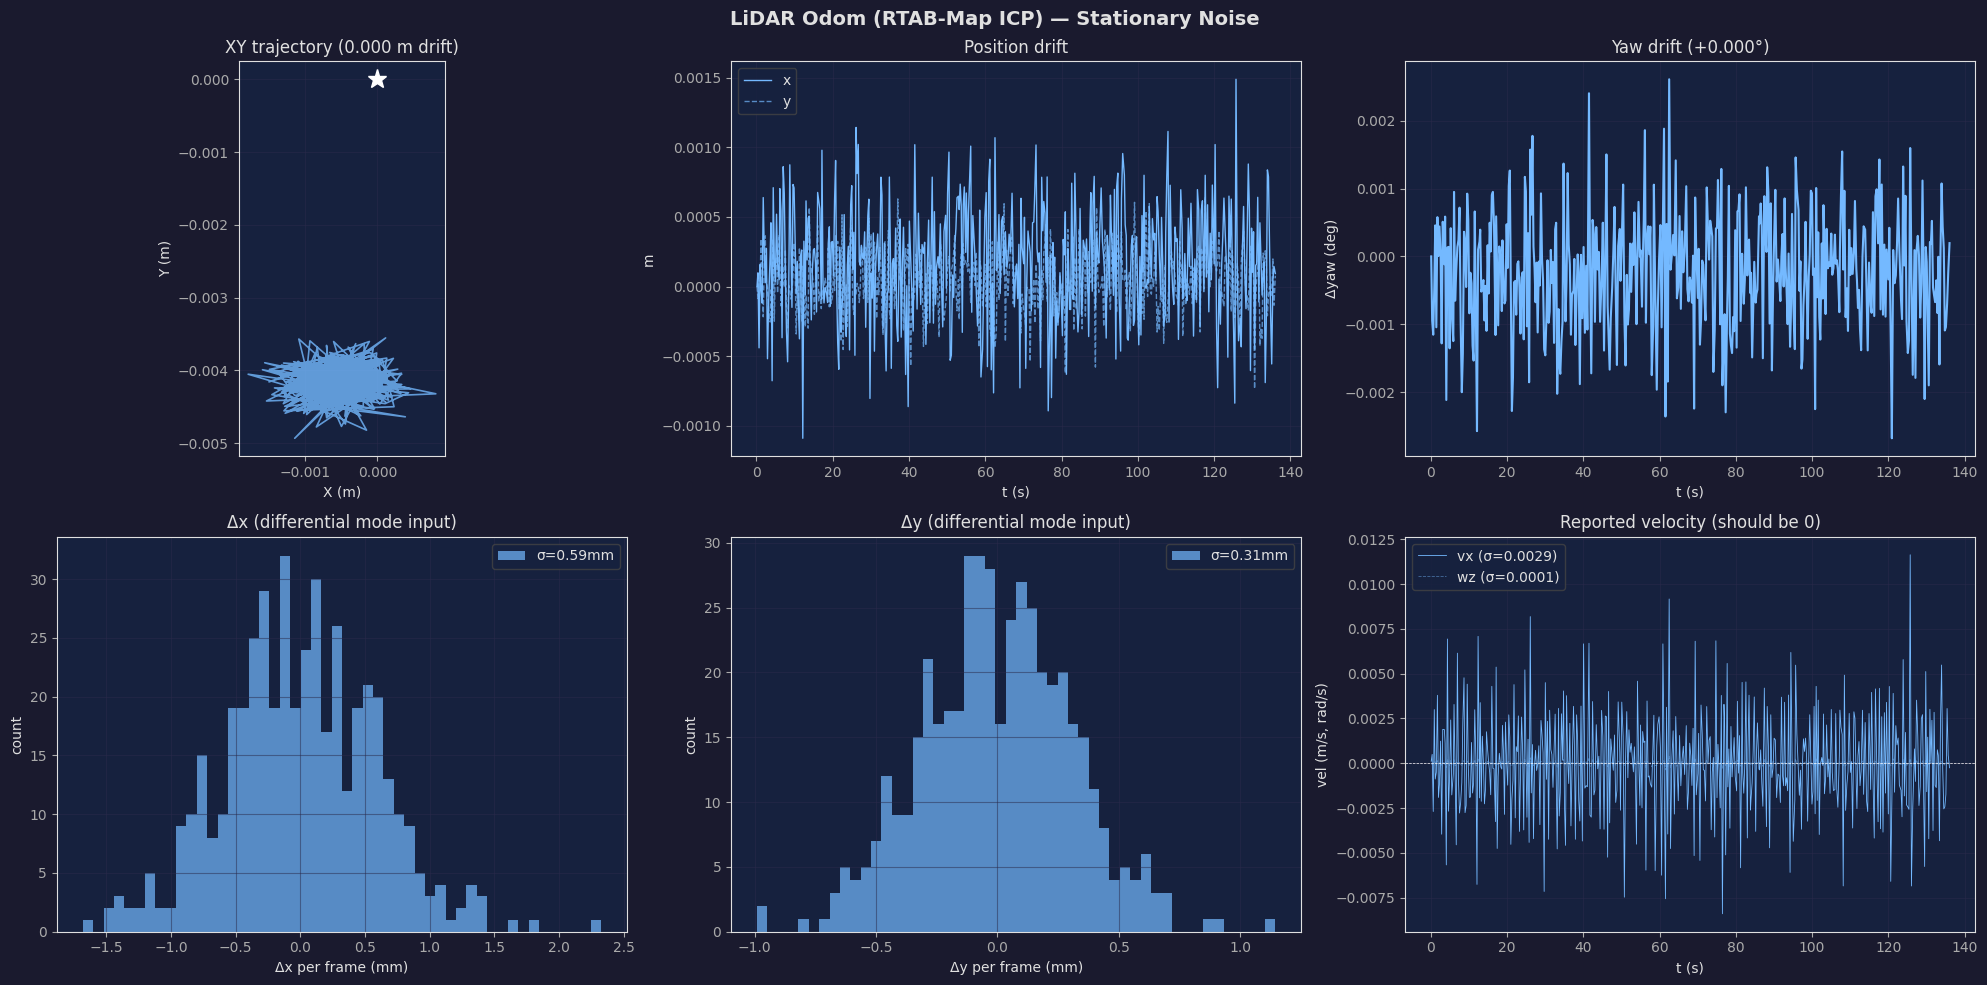

LiDAR Odom (RTAB-Map ICP):
  total drift   : Δx=+0.0001m  Δy=+0.0001m  |Δr|=0.0001m
  yaw drift     : +0.000°
  per-frame Δ σ : x=0.587mm  y=0.310mm  yaw=0.0012°
  velocity σ    : vx=0.00293 m/s  wz=0.00011 rad/s



In [108]:
for k, name, color in [('visual', 'Visual Odom (RTAB-Map RGB-D)', C['visual']),
                       ('lidar',  'LiDAR Odom (RTAB-Map ICP)',     C['lidar'])]:
    if k not in dfs:
        print(f'No /odometry/{k} in bag'); continue
    d = dfs[k]
    t = npc(d,'t'); x = npc(d,'x'); y = npc(d,'y')
    yaw = np.degrees(np.unwrap(npc(d,'yaw')))
    vx = npc(d,'vx'); wz = npc(d,'wz')

    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle(f'{name} — Stationary Noise', fontsize=14, fontweight='bold')

    # XY trajectory
    axes[0,0].plot(x, y, color=color, lw=1.2, alpha=0.8)
    axes[0,0].plot(0, 0, 'w*', ms=14)
    axes[0,0].set_xlabel('X (m)'); axes[0,0].set_ylabel('Y (m)')
    axes[0,0].set_title(f'XY trajectory ({np.hypot(x[-1]-x[0], y[-1]-y[0]):.3f} m drift)')
    axes[0,0].set_aspect('equal'); axes[0,0].grid(True)

    # X,Y vs time
    axes[0,1].plot(t, x - x[0], color=color, label='x', lw=1)
    axes[0,1].plot(t, y - y[0], color=color, label='y', lw=1, ls='--', alpha=0.7)
    axes[0,1].set_xlabel('t (s)'); axes[0,1].set_ylabel('m')
    axes[0,1].set_title('Position drift'); axes[0,1].legend(); axes[0,1].grid(True)

    # Yaw vs time
    axes[0,2].plot(t, yaw - yaw[0], color=color)
    axes[0,2].set_xlabel('t (s)'); axes[0,2].set_ylabel('Δyaw (deg)')
    axes[0,2].set_title(f'Yaw drift ({yaw[-1]-yaw[0]:+.3f}°)'); axes[0,2].grid(True)

    # Frame-to-frame deltas (what EKF sees in differential mode)
    dx = np.diff(x); dy = np.diff(y); dyaw = np.diff(np.unwrap(npc(d,'yaw')))
    axes[1,0].hist(dx*1000, bins=50, alpha=0.7, color=color, label=f'σ={dx.std()*1000:.2f}mm')
    axes[1,0].set_xlabel('Δx per frame (mm)'); axes[1,0].set_ylabel('count')
    axes[1,0].set_title('Δx (differential mode input)'); axes[1,0].legend(); axes[1,0].grid(True)

    axes[1,1].hist(dy*1000, bins=50, alpha=0.7, color=color, label=f'σ={dy.std()*1000:.2f}mm')
    axes[1,1].set_xlabel('Δy per frame (mm)'); axes[1,1].set_ylabel('count')
    axes[1,1].set_title('Δy (differential mode input)'); axes[1,1].legend(); axes[1,1].grid(True)

    axes[1,2].plot(t, vx, color=color, lw=0.6, label=f'vx (σ={vx.std():.4f})')
    axes[1,2].plot(t, wz, color=color, lw=0.6, alpha=0.5, ls='--', label=f'wz (σ={wz.std():.4f})')
    axes[1,2].axhline(0, color='white', ls='--', lw=0.5)
    axes[1,2].set_xlabel('t (s)'); axes[1,2].set_ylabel('vel (m/s, rad/s)')
    axes[1,2].set_title('Reported velocity (should be 0)'); axes[1,2].legend(); axes[1,2].grid(True)

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/02b_{k}_odom.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'{name}:')
    print(f'  total drift   : Δx={x[-1]-x[0]:+.4f}m  Δy={y[-1]-y[0]:+.4f}m  |Δr|={np.hypot(x[-1]-x[0],y[-1]-y[0]):.4f}m')
    print(f'  yaw drift     : {yaw[-1]-yaw[0]:+.3f}°')
    print(f'  per-frame Δ σ : x={dx.std()*1000:.3f}mm  y={dy.std()*1000:.3f}mm  yaw={np.degrees(dyaw).std():.4f}°')
    print(f'  velocity σ    : vx={vx.std():.5f} m/s  wz={wz.std():.5f} rad/s')
    print()

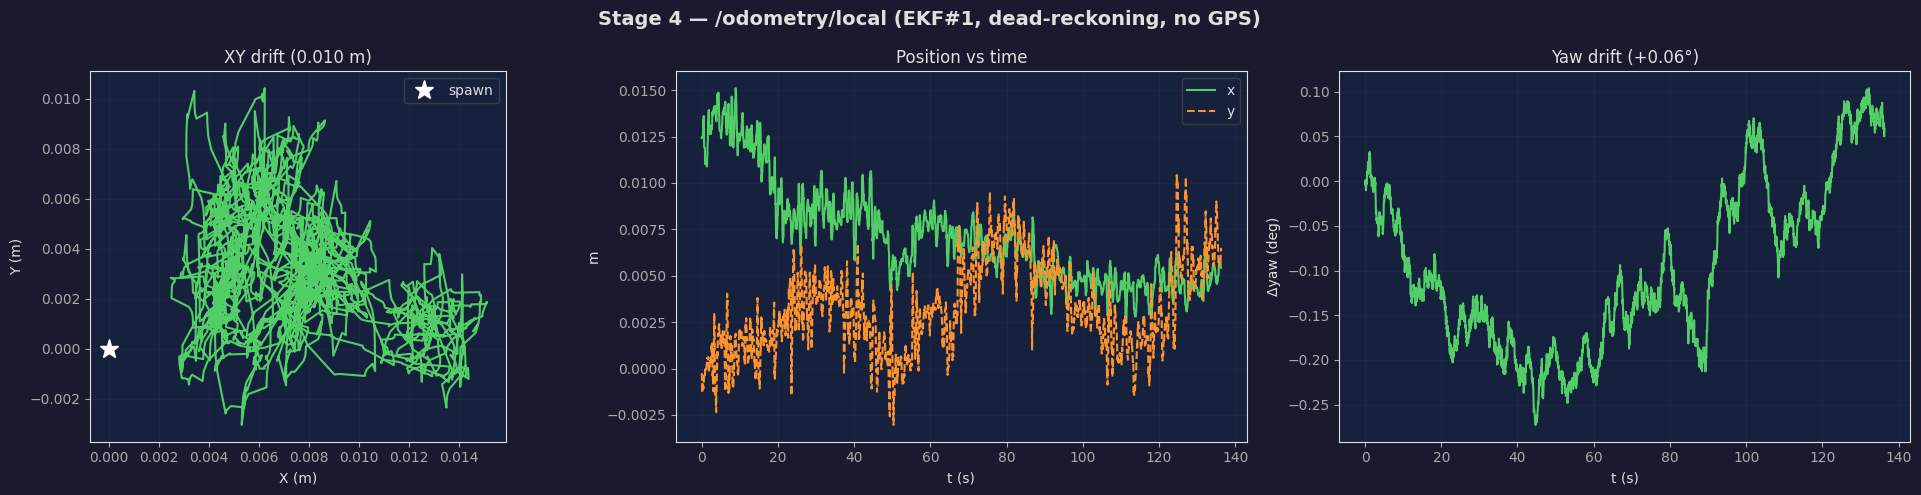

EKF#1 stationary drift:  Δx=-0.0070m  Δy=+0.0068m  Δyaw=+0.058°


In [109]:
if 'ekf_local' in dfs:
    el = dfs['ekf_local']
    t = npc(el,'t'); x = npc(el,'x'); y = npc(el,'y'); yaw = np.degrees(npc(el,'yaw'))
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle('Stage 4 — /odometry/local (EKF#1, dead-reckoning, no GPS)', fontsize=14, fontweight='bold')
    axes[0].plot(x, y, color=C['ekf_local'], lw=1.5)
    axes[0].plot(0, 0, 'w*', ms=14, label='spawn')
    axes[0].set_xlabel('X (m)'); axes[0].set_ylabel('Y (m)')
    axes[0].set_title(f'XY drift ({np.hypot(x[-1]-x[0], y[-1]-y[0]):.3f} m)')
    axes[0].set_aspect('equal'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(t, x, label='x', color=C['ekf_local'])
    axes[1].plot(t, y, label='y', color=C['gps_relay'], ls='--')
    axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('m')
    axes[1].set_title('Position vs time'); axes[1].legend(); axes[1].grid(True)
    axes[2].plot(t, yaw - yaw[0], color=C['ekf_local'])
    axes[2].set_xlabel('t (s)'); axes[2].set_ylabel('Δyaw (deg)')
    axes[2].set_title(f'Yaw drift ({yaw[-1]-yaw[0]:+.2f}°)'); axes[2].grid(True)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/03_ekf_local.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'EKF#1 stationary drift:  Δx={x[-1]-x[0]:+.4f}m  Δy={y[-1]-y[0]:+.4f}m  Δyaw={yaw[-1]-yaw[0]:+.3f}°')
else:
    print('No /odometry/local')

## 6. Stage 5 — `/odometry/global` (EKF#2, with GPS)

**This is the suspect.** If global drifts more than local → GPS pulls EKF#2 around.
If global drifts less → GPS helping. If global rotates while stationary → P[x,θ] yaw coupling.

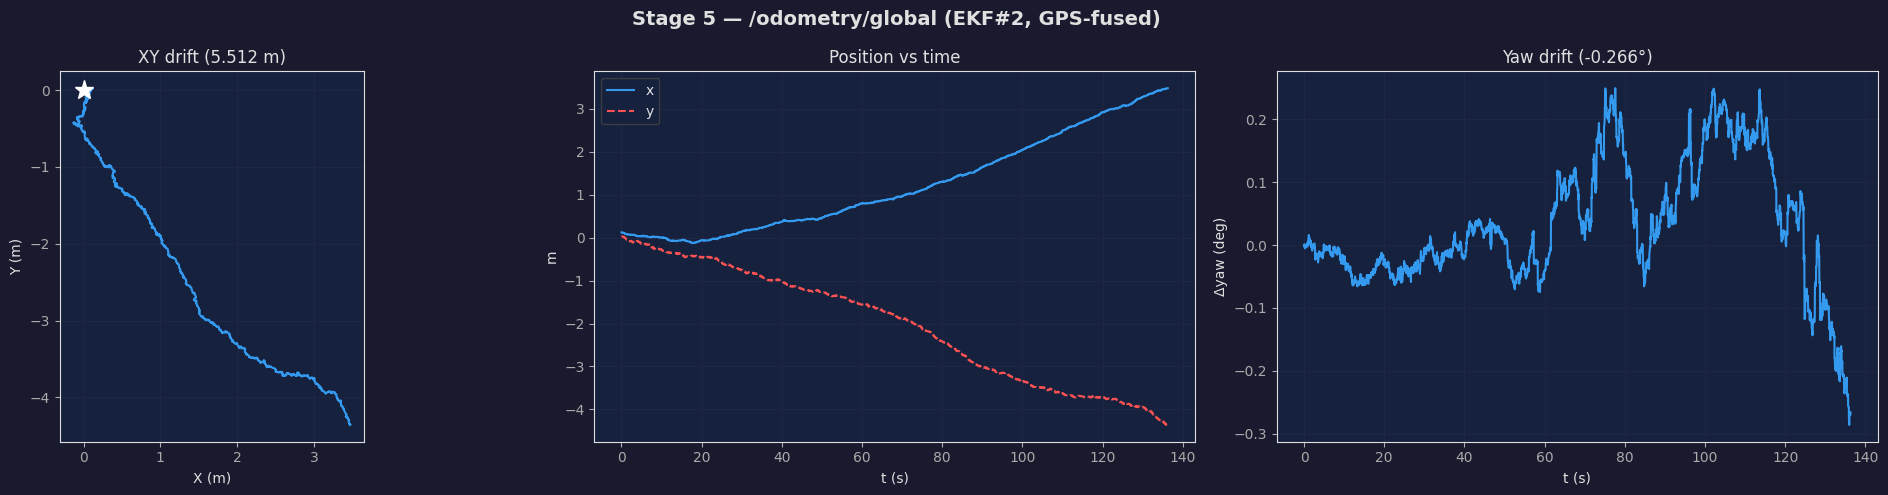

EKF#2 stationary drift:  Δx=+3.3526m  Δy=-4.3752m  Δyaw=-0.266°


In [110]:
if 'ekf_global' in dfs:
    eg = dfs['ekf_global']
    t = npc(eg,'t'); x = npc(eg,'x'); y = npc(eg,'y'); yaw = np.degrees(npc(eg,'yaw'))
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle('Stage 5 — /odometry/global (EKF#2, GPS-fused)', fontsize=14, fontweight='bold')
    axes[0].plot(x, y, color=C['ekf_global'], lw=1.5)
    axes[0].plot(0, 0, 'w*', ms=14)
    axes[0].set_xlabel('X (m)'); axes[0].set_ylabel('Y (m)')
    axes[0].set_title(f'XY drift ({np.hypot(x[-1]-x[0], y[-1]-y[0]):.3f} m)')
    axes[0].set_aspect('equal'); axes[0].grid(True)
    axes[1].plot(t, x, label='x', color=C['ekf_global'])
    axes[1].plot(t, y, label='y', color=C['odom_gps'], ls='--')
    axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('m')
    axes[1].set_title('Position vs time'); axes[1].legend(); axes[1].grid(True)
    axes[2].plot(t, yaw - yaw[0], color=C['ekf_global'])
    axes[2].set_xlabel('t (s)'); axes[2].set_ylabel('Δyaw (deg)')
    axes[2].set_title(f'Yaw drift ({yaw[-1]-yaw[0]:+.3f}°)'); axes[2].grid(True)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/04_ekf_global.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'EKF#2 stationary drift:  Δx={x[-1]-x[0]:+.4f}m  Δy={y[-1]-y[0]:+.4f}m  Δyaw={yaw[-1]-yaw[0]:+.3f}°')

## 7. Pipeline Overlay — Who Diverges First?

All stages on one XY plot, colored by stage. Arrow = direction of drift. Reveals which node introduces motion first.

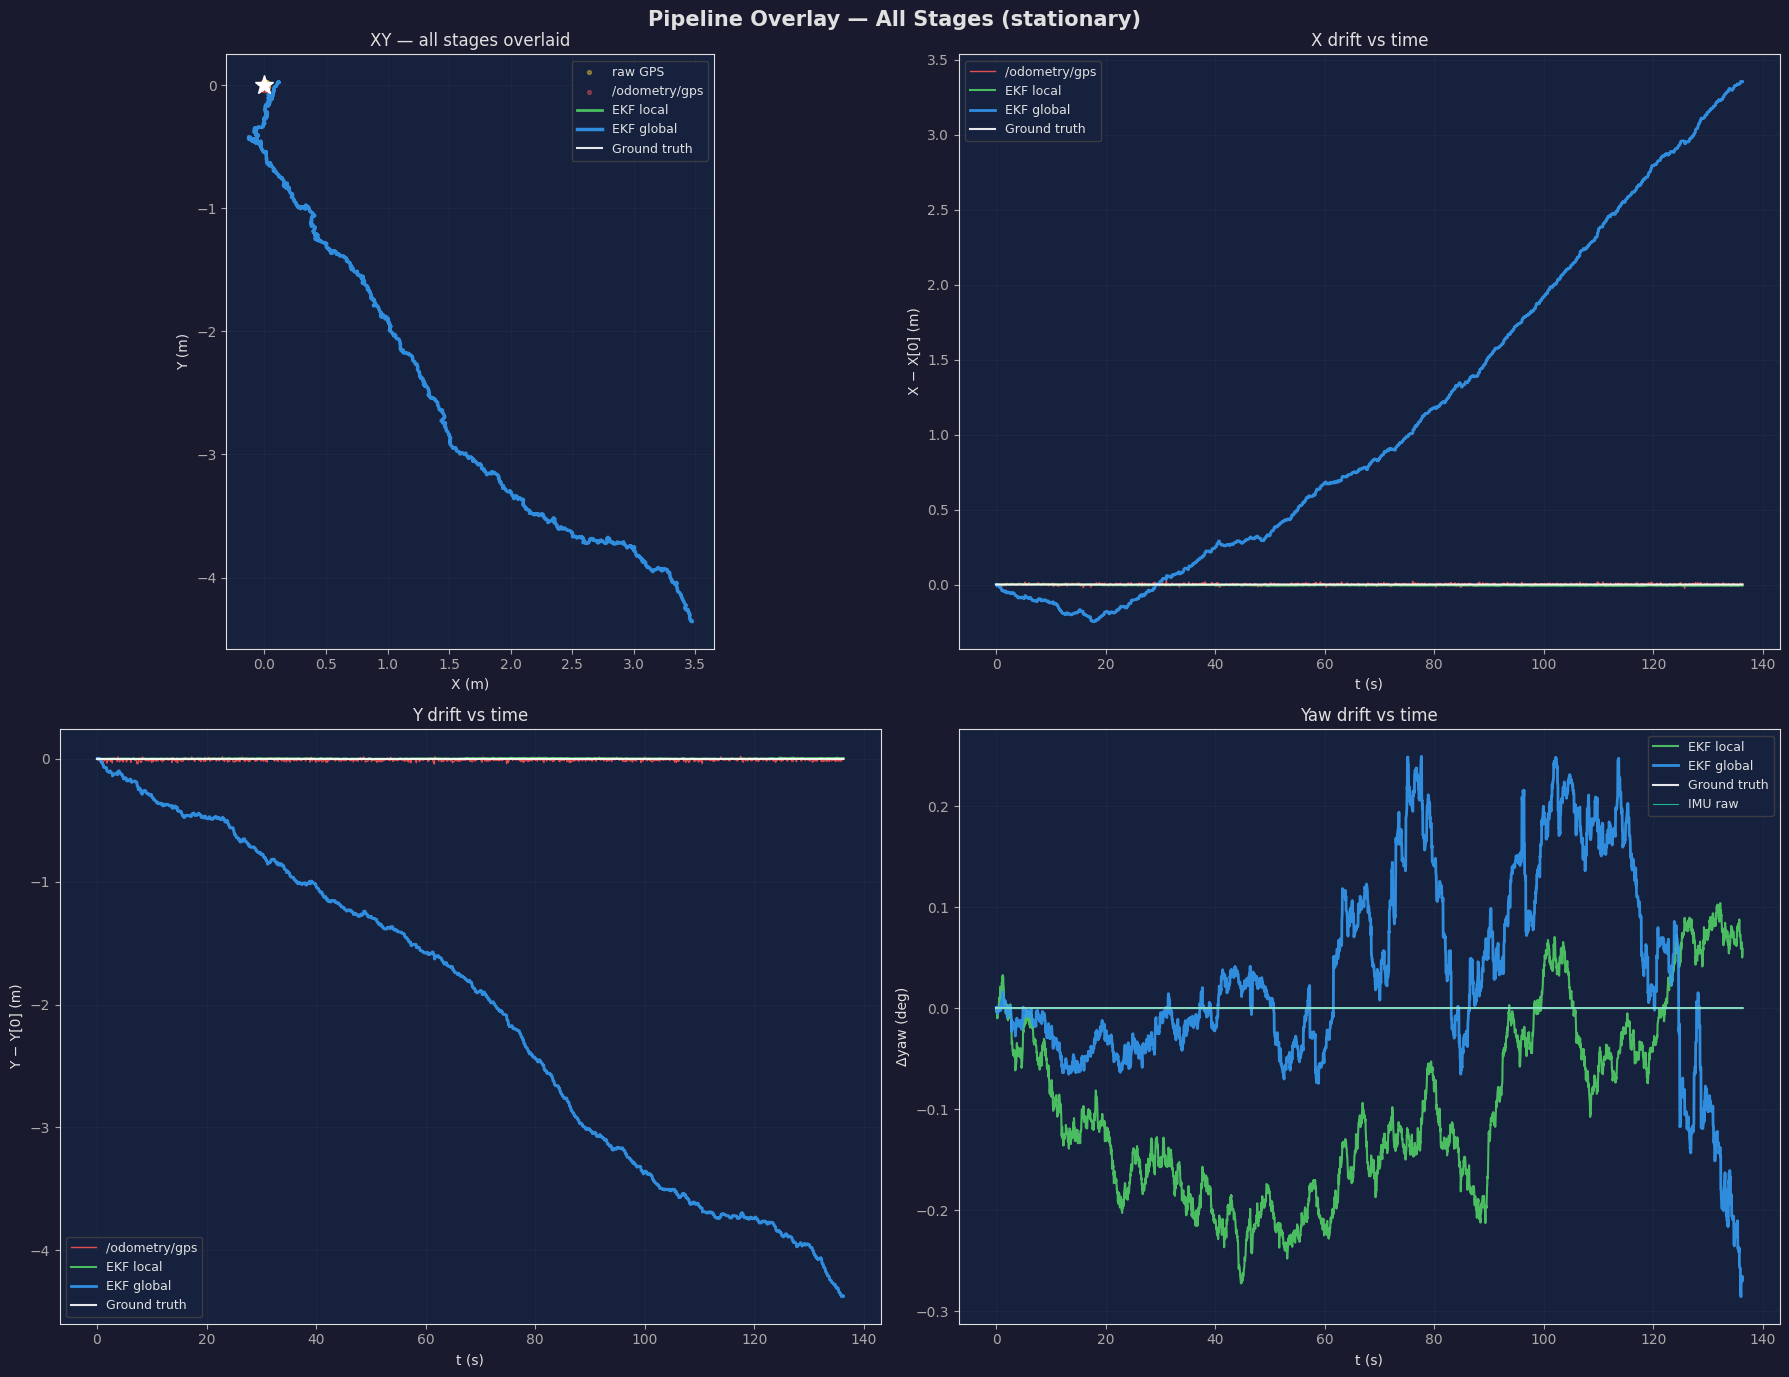

In [111]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Pipeline Overlay — All Stages (stationary)', fontsize=15, fontweight='bold')

# XY scatter
ax = axes[0,0]
if 'gps_raw' in dfs:
    g = dfs['gps_raw']; lat=npc(g,'lat'); lon=npc(g,'lon')
    xp=(lon-lon[0])*111320*np.cos(np.radians(lat[0]))
    yp=(lat-lat[0])*111320
    ax.scatter(xp, yp, c=C['gps_raw'], s=8, alpha=0.4, label='raw GPS')
if 'odom_gps' in dfs:
    og=dfs['odom_gps']; ax.scatter(npc(og,'x')-npc(og,'x')[0], npc(og,'y')-npc(og,'y')[0],
                                     c=C['odom_gps'], s=8, alpha=0.4, label='/odometry/gps')
for k, lbl, col, lw in [('ekf_local','EKF local',C['ekf_local'],2),
                         ('ekf_global','EKF global',C['ekf_global'],2.5),
                         ('ground_truth','Ground truth',C['ground_truth'],1.5)]:
    if k in dfs:
        d=dfs[k]; ax.plot(npc(d,'x'), npc(d,'y'), color=col, lw=lw, label=lbl, alpha=0.9)
ax.plot(0, 0, 'w*', ms=14, zorder=10)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('XY — all stages overlaid')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.grid(True)

# X vs time
ax = axes[0,1]
for k, lbl, col, lw in [('odom_gps','/odometry/gps',C['odom_gps'],1),
                         ('ekf_local','EKF local',C['ekf_local'],1.5),
                         ('ekf_global','EKF global',C['ekf_global'],2),
                         ('ground_truth','Ground truth',C['ground_truth'],1.5)]:
    if k in dfs:
        d=dfs[k]; t=npc(d,'t'); x=npc(d,'x')
        ax.plot(t, x - x[0], color=col, lw=lw, label=lbl, alpha=0.9)
ax.set_xlabel('t (s)'); ax.set_ylabel('X − X[0] (m)')
ax.set_title('X drift vs time')
ax.legend(fontsize=9); ax.grid(True)

# Y vs time
ax = axes[1,0]
for k, lbl, col, lw in [('odom_gps','/odometry/gps',C['odom_gps'],1),
                         ('ekf_local','EKF local',C['ekf_local'],1.5),
                         ('ekf_global','EKF global',C['ekf_global'],2),
                         ('ground_truth','Ground truth',C['ground_truth'],1.5)]:
    if k in dfs:
        d=dfs[k]; t=npc(d,'t'); y=npc(d,'y')
        ax.plot(t, y - y[0], color=col, lw=lw, label=lbl, alpha=0.9)
ax.set_xlabel('t (s)'); ax.set_ylabel('Y − Y[0] (m)')
ax.set_title('Y drift vs time')
ax.legend(fontsize=9); ax.grid(True)

# Yaw vs time
ax = axes[1,1]
for k, lbl, col, lw in [('ekf_local','EKF local',C['ekf_local'],1.5),
                         ('ekf_global','EKF global',C['ekf_global'],2),
                         ('ground_truth','Ground truth',C['ground_truth'],1.5),
                         ('imu','IMU raw',C['imu'],0.8)]:
    if k in dfs:
        d=dfs[k]; t=npc(d,'t'); yw=np.degrees(npc(d,'yaw'))
        ax.plot(t, yw - yw[0], color=col, lw=lw, label=lbl, alpha=0.9)
ax.set_xlabel('t (s)'); ax.set_ylabel('Δyaw (deg)')
ax.set_title('Yaw drift vs time')
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/05_pipeline_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. IMU Stationary Noise (yaw drift root cause check)

Gyro Z bias × time = yaw drift. If accelerometer X/Y bias > process noise → fake "acceleration" → EKF integrates as fake velocity → fake position drift.

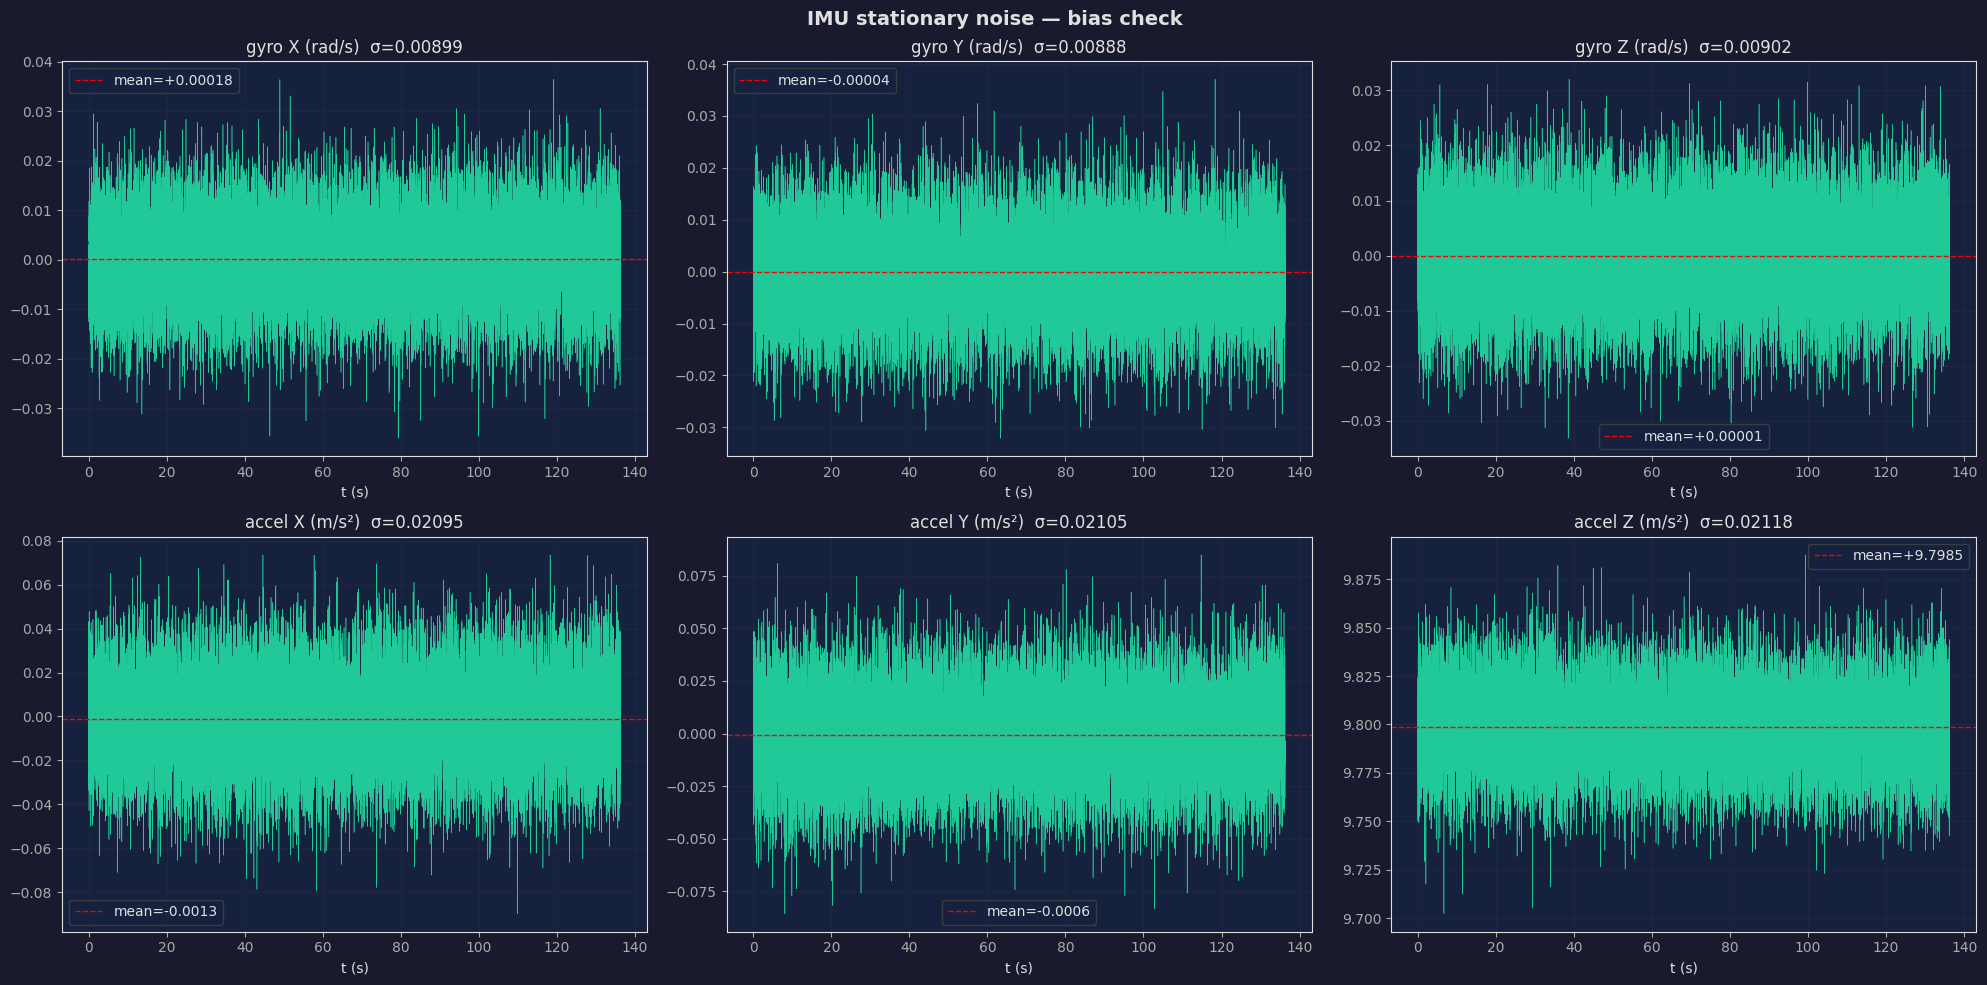


IMU bias-induced drift estimates over 136.3s stationary:
  gyro Z bias = +0.00001 rad/s  →  yaw drift = +0.059°
  accel X bias = -0.0013 m/s²  →  pos drift = -12.193 m
  accel Y bias = -0.0006 m/s²  →  pos drift = -5.787 m


In [112]:
if 'imu' in dfs:
    im = dfs['imu']
    t = npc(im,'t')
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle('IMU stationary noise — bias check', fontsize=14, fontweight='bold')
    for i, ch in enumerate(['gx','gy','gz']):
        d = npc(im, ch)
        m = mfin(t, d)
        axes[0,i].plot(t[m], d[m], color=C['imu'], lw=0.4)
        axes[0,i].axhline(d[m].mean(), color='red', ls='--', lw=1, label=f'mean={d[m].mean():+.5f}')
        axes[0,i].set_title(f'gyro {ch[1].upper()} (rad/s)  σ={d[m].std():.5f}')
        axes[0,i].set_xlabel('t (s)'); axes[0,i].legend(); axes[0,i].grid(True)
    for i, ch in enumerate(['ax','ay','az']):
        d = npc(im, ch)
        m = mfin(t, d)
        axes[1,i].plot(t[m], d[m], color=C['imu'], lw=0.4)
        axes[1,i].axhline(d[m].mean(), color='red', ls='--', lw=1, label=f'mean={d[m].mean():+.4f}')
        axes[1,i].set_title(f'accel {ch[1].upper()} (m/s²)  σ={d[m].std():.5f}')
        axes[1,i].set_xlabel('t (s)'); axes[1,i].legend(); axes[1,i].grid(True)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/06_imu_bias.png', dpi=150, bbox_inches='tight')
    plt.show()

    gz = npc(im,'gz'); gz_bias = gz[mfin(t,gz)].mean()
    dur = t[-1]-t[0]
    print(f'\nIMU bias-induced drift estimates over {dur:.1f}s stationary:')
    print(f'  gyro Z bias = {gz_bias:+.5f} rad/s  →  yaw drift = {np.degrees(gz_bias*dur):+.3f}°')
    for ch in ['ax','ay']:
        b = npc(im,ch); b = b[mfin(t,b)].mean()
        # double-integrate constant bias: Δx = 0.5 * b * t²
        print(f'  accel {ch[1].upper()} bias = {b:+.4f} m/s²  →  pos drift = {0.5*b*dur**2:+.3f} m')

## 9. EKF#2 Innovation = `/odometry/gps` − EKF prediction

Innovation should be zero-mean Gaussian. Non-zero mean → systematic offset. Wide spread relative to claimed σ → covariance underestimated → K too high → EKF chases noise.

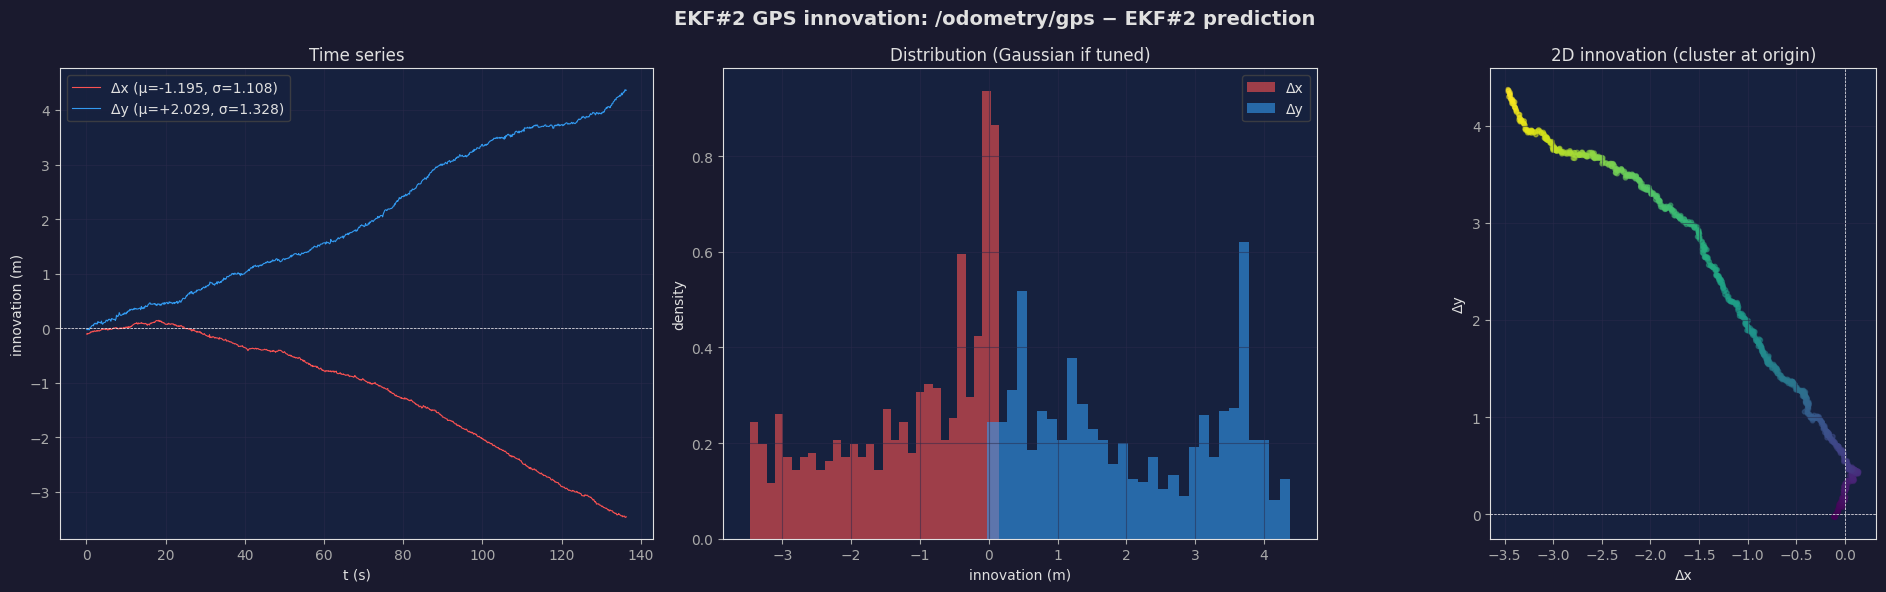


Innovation RMSE = 2.9213 m
  EKF#2 claimed σ_GPS = sqrt(R) where R from relay = sqrt(9.0) = 3.0 m
  Measured innovation σ: x=1.108m  y=1.328m


In [113]:
if 'odom_gps' in dfs and 'ekf_global' in dfs:
    og = dfs['odom_gps']; eg = dfs['ekf_global']
    tg = npc(og,'t'); xg = npc(og,'x'); yg = npc(og,'y')
    te = npc(eg,'t'); xe = npc(eg,'x'); ye = npc(eg,'y')
    me = mfin(te, xe, ye); mg = mfin(tg, xg, yg)
    xe_at_g = np.interp(tg[mg], te[me], xe[me])
    ye_at_g = np.interp(tg[mg], te[me], ye[me])
    inx = xg[mg] - xe_at_g
    iny = yg[mg] - ye_at_g

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('EKF#2 GPS innovation: /odometry/gps − EKF#2 prediction', fontsize=14, fontweight='bold')
    axes[0].plot(tg[mg], inx, color=C['odom_gps'], lw=0.8, label=f'Δx (μ={inx.mean():+.3f}, σ={inx.std():.3f})')
    axes[0].plot(tg[mg], iny, color=C['ekf_global'], lw=0.8, label=f'Δy (μ={iny.mean():+.3f}, σ={iny.std():.3f})')
    axes[0].axhline(0, color='white', ls='--', lw=0.5)
    axes[0].set_xlabel('t (s)'); axes[0].set_ylabel('innovation (m)')
    axes[0].set_title('Time series'); axes[0].legend(); axes[0].grid(True)

    axes[1].hist(inx, bins=30, alpha=0.6, color=C['odom_gps'], density=True, label='Δx')
    axes[1].hist(iny, bins=30, alpha=0.6, color=C['ekf_global'], density=True, label='Δy')
    axes[1].set_xlabel('innovation (m)'); axes[1].set_ylabel('density')
    axes[1].set_title('Distribution (Gaussian if tuned)'); axes[1].legend(); axes[1].grid(True)

    axes[2].scatter(inx, iny, c=tg[mg], cmap='viridis', s=10, alpha=0.5)
    axes[2].axhline(0, color='white', ls='--', lw=0.5); axes[2].axvline(0, color='white', ls='--', lw=0.5)
    axes[2].set_xlabel('Δx'); axes[2].set_ylabel('Δy')
    axes[2].set_title('2D innovation (cluster at origin)')
    axes[2].set_aspect('equal'); axes[2].grid(True)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/07_ekf2_innovation.png', dpi=150, bbox_inches='tight')
    plt.show()

    rmse = np.sqrt(np.mean(inx**2 + iny**2))
    print(f'\nInnovation RMSE = {rmse:.4f} m')
    print(f'  EKF#2 claimed σ_GPS = sqrt(R) where R from relay = sqrt(9.0) = 3.0 m')
    print(f'  Measured innovation σ: x={inx.std():.3f}m  y={iny.std():.3f}m')
    if max(inx.std(), iny.std()) > 3.0:
        print('  ⚠ Innovation σ > claimed R → covariance underestimated, EKF too aggressive')

## 10. Per-Stage Drift Attribution Table

Quantify drift contribution per stage. Pipeline order:
1. Raw GPS scatter (Gazebo plugin)
2. navsat projection error (raw → /odometry/gps)
3. EKF#1 dead-reckoning (IMU/wheel only)
4. EKF#2 GPS-fused

Compare each to ground truth.

In [114]:
rows = []
def stat_block(name, t, x, y, yaw=None):
    return {
        'stage': name,
        'σ_x (m)': float(x.std()),
        'σ_y (m)': float(y.std()),
        'Δx end (m)': float(x[-1]-x[0]),
        'Δy end (m)': float(y[-1]-y[0]),
        '|Δr end| (m)': float(np.hypot(x[-1]-x[0], y[-1]-y[0])),
        'Δyaw (deg)': float(np.degrees(yaw[-1]-yaw[0])) if yaw is not None else float('nan'),
        'duration (s)': float(t[-1]-t[0]),
    }

if 'gps_raw' in dfs:
    g = dfs['gps_raw']; lat=npc(g,'lat'); lon=npc(g,'lon'); t=npc(g,'t')
    xp=(lon-lon[0])*111320*np.cos(np.radians(lat[0]))
    yp=(lat-lat[0])*111320
    rows.append(stat_block('1. raw /gps/fix', t, xp, yp))

for k, name in [('odom_gps','3. /odometry/gps'),
                ('ekf_local','4. /odometry/local (EKF#1)'),
                ('ekf_global','5. /odometry/global (EKF#2)'),
                ('ground_truth','6. /ground_truth/odom')]:
    if k in dfs:
        d = dfs[k]
        t = npc(d,'t'); x = npc(d,'x'); y = npc(d,'y'); yw = npc(d,'yaw')
        rows.append(stat_block(name, t, x-x[0], y-y[0], np.unwrap(yw)))

summary = pd.DataFrame(rows)
for c in summary.columns[1:]:
    summary[c] = summary[c].apply(lambda v: f'{v:+.4f}' if isinstance(v, float) else v)
print(summary.to_string(index=False))

                      stage σ_x (m) σ_y (m) Δx end (m) Δy end (m) |Δr end| (m) Δyaw (deg) duration (s)
            1. raw /gps/fix +0.0065 +0.0100    +0.0109    +0.0107      +0.0153       +nan    +136.1610
           3. /odometry/gps +0.0065 +0.0100    +0.0032    +0.0011      +0.0034    +0.0000    +136.2043
 4. /odometry/local (EKF#1) +0.0028 +0.0024    -0.0070    +0.0068      +0.0097    +0.0585    +136.2557
5. /odometry/global (EKF#2) +1.1059 +1.3258    +3.3526    -4.3752      +5.5120    -0.2665    +136.2556
      6. /ground_truth/odom +0.0000 +0.0000    +0.0000    +0.0000      +0.0000    +0.0000    +136.2559


## 11. Diagnosis Heuristics

Auto-flag the likely culprit based on numbers above.

In [115]:
print('═' * 70)
print('PIPELINE DRIFT DIAGNOSIS')
print('═' * 70)

flags = []

if 'gps_raw' in dfs:
    g = dfs['gps_raw']
    lat=npc(g,'lat'); lon=npc(g,'lon')
    xp=(lon-lon[0])*111320*np.cos(np.radians(lat[0]))
    yp=(lat-lat[0])*111320
    if max(xp.std(), yp.std()) > 1.5:
        flags.append(f'⚠ Gazebo NavSat plugin: scatter σ={max(xp.std(),yp.std()):.2f}m >> URDF stddev (~0.5m). '
                     'Plugin likely adds random walk on top of stddev.')
    drift_gps = np.hypot(xp[-1]-xp[0], yp[-1]-yp[0])
    if drift_gps > 3 * max(xp.std(), yp.std()):
        flags.append(f'⚠ Raw GPS shows DRIFT not just scatter (Δr={drift_gps:.2f}m). '
                     'Bias or biased random walk in NavSat plugin.')

if 'ekf_local' in dfs:
    el = dfs['ekf_local']; x=npc(el,'x'); y=npc(el,'y'); yaw=npc(el,'yaw')
    drift_l = np.hypot(x[-1]-x[0], y[-1]-y[0])
    yawd = np.degrees(yaw[-1]-yaw[0])
    if drift_l > 0.5:
        flags.append(f'⚠ EKF#1 dead-reckoning drifts {drift_l:.2f}m → IMU/wheel bias leaking. '
                     'Check imu0_differential, accel bias, wheel slip.')
    if abs(yawd) > 1.0:
        flags.append(f'⚠ EKF#1 yaw drift {yawd:+.2f}° stationary → gyro Z bias not zero or differential mode broken.')

if 'ekf_global' in dfs and 'ekf_local' in dfs:
    eg = dfs['ekf_global']; el = dfs['ekf_local']
    drift_g = np.hypot(npc(eg,'x')[-1]-npc(eg,'x')[0], npc(eg,'y')[-1]-npc(eg,'y')[0])
    drift_l = np.hypot(npc(el,'x')[-1]-npc(el,'x')[0], npc(el,'y')[-1]-npc(el,'y')[0])
    if drift_g > drift_l + 0.2:
        flags.append(f'⚠ EKF#2 (GPS-fused) drifts MORE than EKF#1 (Δglobal={drift_g:.2f}m vs Δlocal={drift_l:.2f}m). '
                     'GPS is dragging EKF#2 around. Either lower navsat freq, raise relay variance, or tighten odom3_pose_rejection_threshold.')
    yawg = np.degrees(npc(eg,'yaw')[-1] - npc(eg,'yaw')[0])
    yawl = np.degrees(npc(el,'yaw')[-1] - npc(el,'yaw')[0])
    if abs(yawg - yawl) > 1.0:
        flags.append(f'⚠ EKF#2 yaw drift {yawg:+.2f}° vs EKF#1 {yawl:+.2f}° → P[x,θ] coupling. '
                     'GPS x,y updates pulling yaw via cross-covariance terms.')

for vk, vname in [('visual', 'Visual'), ('lidar', 'LiDAR')]:
    if vk in dfs:
        v = dfs[vk]
        vd = np.hypot(npc(v,'x')[-1]-npc(v,'x')[0], npc(v,'y')[-1]-npc(v,'y')[0])
        vy = np.degrees(npc(v,'yaw')[-1] - npc(v,'yaw')[0])
        if vd > 0.05:
            flags.append(f'⚠ {vname} odom drifts {vd:.3f}m stationary → injects motion in EKF#2 differential mode.')
        if abs(vy) > 0.5:
            flags.append(f'⚠ {vname} odom yaw drifts {vy:+.2f}° stationary → yaw delta input to EKF#2.')

if 'imu' in dfs:
    gz = npc(dfs['imu'],'gz')
    if abs(gz.mean()) > 1e-3:
        flags.append(f'⚠ IMU gyro Z bias = {gz.mean():+.5f} rad/s (non-zero). '
                     'Even differential mode may leak via bias_stddev. URDF dynamic_bias_stddev tuning needed.')

if not flags:
    print('✓ No drift flags raised — pipeline appears stable.')
else:
    for f in flags: print(f)
    print('\nNext steps:')
    print('  1. If raw GPS itself drifts → switch to RTK-grade noise in URDF (stddev=9e-8 deg).')
    print('  2. If only EKF#2 drifts → tighten odom3_pose_rejection_threshold OR raise relay variance.')
    print('  3. If yaw coupling → bump EKF#2 vyaw process noise; verify use_odometry_yaw=true.')
    print('  4. If EKF#1 drifts → re-tune imu0 differential mode, wheel velocity covariance.')

══════════════════════════════════════════════════════════════════════
PIPELINE DRIFT DIAGNOSIS
══════════════════════════════════════════════════════════════════════
⚠ EKF#2 (GPS-fused) drifts MORE than EKF#1 (Δglobal=5.51m vs Δlocal=0.01m). GPS is dragging EKF#2 around. Either lower navsat freq, raise relay variance, or tighten odom3_pose_rejection_threshold.

Next steps:
  1. If raw GPS itself drifts → switch to RTK-grade noise in URDF (stddev=9e-8 deg).
  2. If only EKF#2 drifts → tighten odom3_pose_rejection_threshold OR raise relay variance.
  3. If yaw coupling → bump EKF#2 vyaw process noise; verify use_odometry_yaw=true.
  4. If EKF#1 drifts → re-tune imu0 differential mode, wheel velocity covariance.
